<a href="https://colab.research.google.com/github/Haniya-Imran/ML-Algorithms-Projects/blob/main/Mushroom_Edibility_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Mushroom Edibility Prediction**

# **Project Overview:**
This notebook aims to classify mushrooms as edible or poisonous based on various physical characteristics.
It covers data loading, EDA, preprocessing, model training, and evaluation for accurate classification.

## **Contents:**
* Import Libraries
* Load Dataset
* Dataset Overview
* Exploratory Data Analysis (EDA)
* Data Preprocessing
* Feature Scaling
* Train-Test Split
* Model Training
* Model Evaluation
* Hyperparameter Tuning
* Pipeline
* Final Output
* Conclusion

### **Import Libraries:**

In [ ]:
import warnings
warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, confusion_matrix, roc_curve)
from sklearn.pipeline import Pipeline

### **Dataset load:**

In [ ]:
df = pd.read_csv('mushrooms.csv')

### **Dataset Overview:**

In [ ]:
df.head()

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,...,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,...,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,...,s,w,w,p,w,o,e,n,a,g


In [ ]:
df.tail()

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
8119,e,k,s,n,f,n,a,c,b,y,...,s,o,o,p,o,o,p,b,c,l
8120,e,x,s,n,f,n,a,c,b,y,...,s,o,o,p,n,o,p,b,v,l
8121,e,f,s,n,f,n,a,c,b,n,...,s,o,o,p,o,o,p,b,c,l
8122,p,k,y,n,f,y,f,c,n,b,...,k,w,w,p,w,o,e,w,v,l
8123,e,x,s,n,f,n,a,c,b,y,...,s,o,o,p,o,o,p,o,c,l


In [ ]:
df.shape

(8124, 23)

In [ ]:
df.columns.tolist()

['class',
 'cap-shape',
 'cap-surface',
 'cap-color',
 'bruises',
 'odor',
 'gill-attachment',
 'gill-spacing',
 'gill-size',
 'gill-color',
 'stalk-shape',
 'stalk-root',
 'stalk-surface-above-ring',
 'stalk-surface-below-ring',
 'stalk-color-above-ring',
 'stalk-color-below-ring',
 'veil-type',
 'veil-color',
 'ring-number',
 'ring-type',
 'spore-print-color',
 'population',
 'habitat']

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8124 entries, 0 to 8123
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   class                     8124 non-null   object
 1   cap-shape                 8124 non-null   object
 2   cap-surface               8124 non-null   object
 3   cap-color                 8124 non-null   object
 4   bruises                   8124 non-null   object
 5   odor                      8124 non-null   object
 6   gill-attachment           8124 non-null   object
 7   gill-spacing              8124 non-null   object
 8   gill-size                 8124 non-null   object
 9   gill-color                8124 non-null   object
 10  stalk-shape               8124 non-null   object
 11  stalk-root                8124 non-null   object
 12  stalk-surface-above-ring  8124 non-null   object
 13  stalk-surface-below-ring  8124 non-null   object
 14  stalk-color-above-ring  

In [ ]:
df.describe()

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
count,8124,8124,8124,8124,8124,8124,8124,8124,8124,8124,...,8124,8124,8124,8124,8124,8124,8124,8124,8124,8124
unique,2,6,4,10,2,9,2,2,2,12,...,4,9,9,1,4,3,5,9,6,7
top,e,x,y,n,f,n,f,c,b,b,...,s,w,w,p,w,o,p,w,v,d
freq,4208,3656,3244,2284,4748,3528,7914,6812,5612,1728,...,4936,4464,4384,8124,7924,7488,3968,2388,4040,3148


In [ ]:
df.dtypes

,0
class,object
cap-shape,object
cap-surface,object
cap-color,object
bruises,object
odor,object
gill-attachment,object
gill-spacing,object
gill-size,object
gill-color,object


In [ ]:
df.isnull().sum().to_frame('missing_count')

,missing_count
class,0
cap-shape,0
cap-surface,0
cap-color,0
bruises,0
odor,0
gill-attachment,0
gill-spacing,0
gill-size,0
gill-color,0


In [ ]:
df.duplicated().sum()

np.int64(0)

### **Outliers Section:**

In [ ]:
num_cols = df.select_dtypes(include='number').columns
Q1 = df[num_cols].quantile(0.25)
Q3 = df[num_cols].quantile(0.75)
IQR = Q3 - Q1
outlier_counts = ((df[num_cols] < (Q1-1.5*IQR)) | (df[num_cols] > (Q3+1.5*IQR))).sum().reset_index()
outlier_counts.columns = ['Column', 'outlier_count']
outlier_counts

,Column,outlier_count


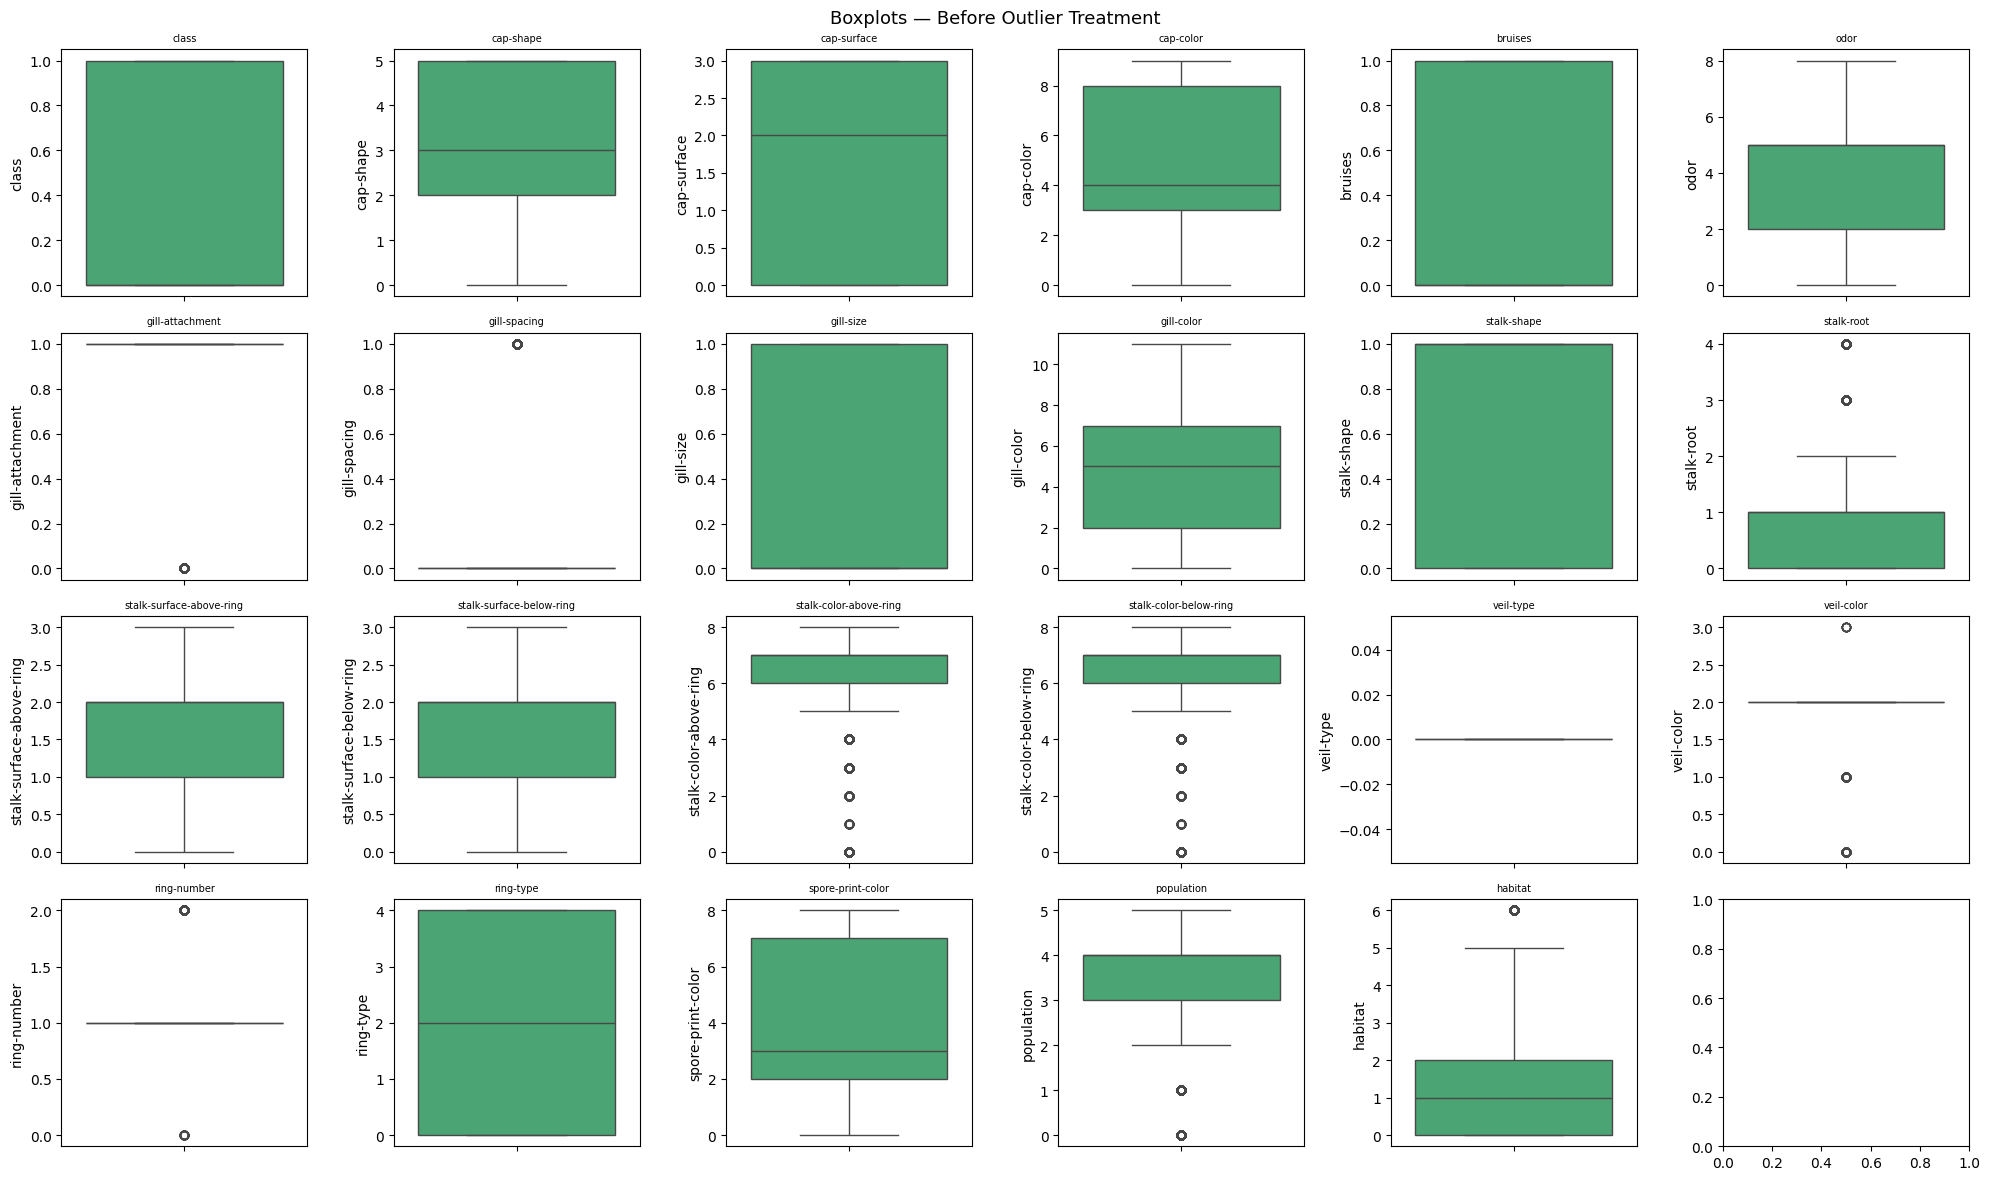

In [ ]:
le_temp = LabelEncoder()
df_num  = df.apply(le_temp.fit_transform)
fig, axes = plt.subplots(4, 6, figsize=(20, 12))
for ax, col in zip(axes.flatten(), df_num.columns):
    sns.boxplot(y=df_num[col], ax=ax, color='mediumseagreen')
    ax.set_title(col, fontsize=7)
plt.suptitle('Boxplots — Before Outlier Treatment', fontsize=13)
plt.tight_layout()
plt.show()

### **Exploratory Data Analysis:**

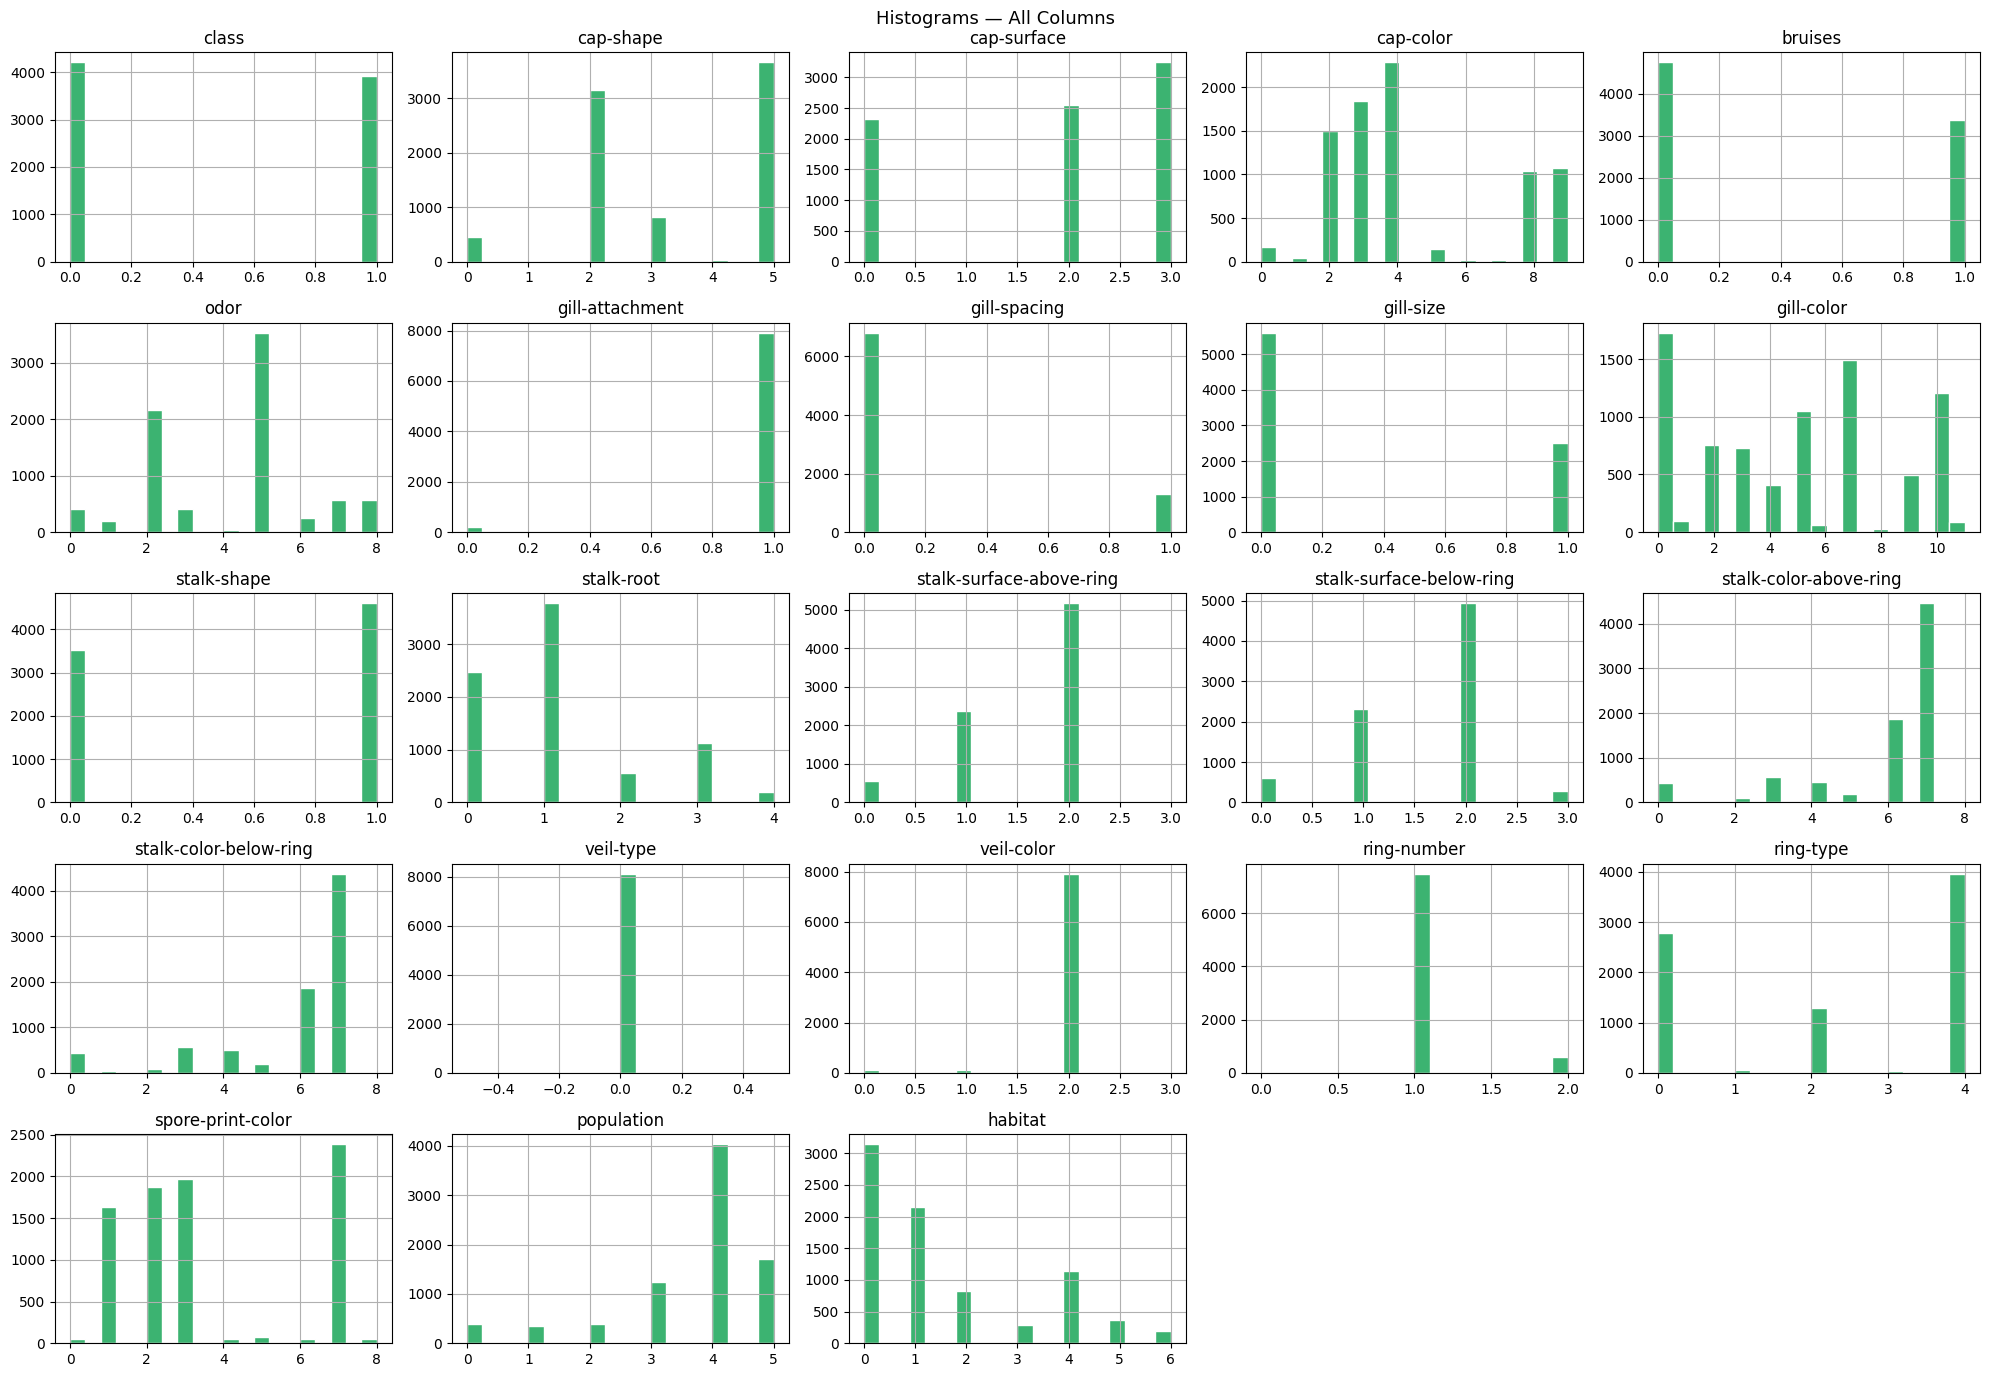

In [ ]:
df_num.hist(bins=20, figsize=(20, 14), color='mediumseagreen', edgecolor='white')
plt.suptitle('Histograms — All Columns', fontsize=13)
plt.tight_layout()
plt.show()

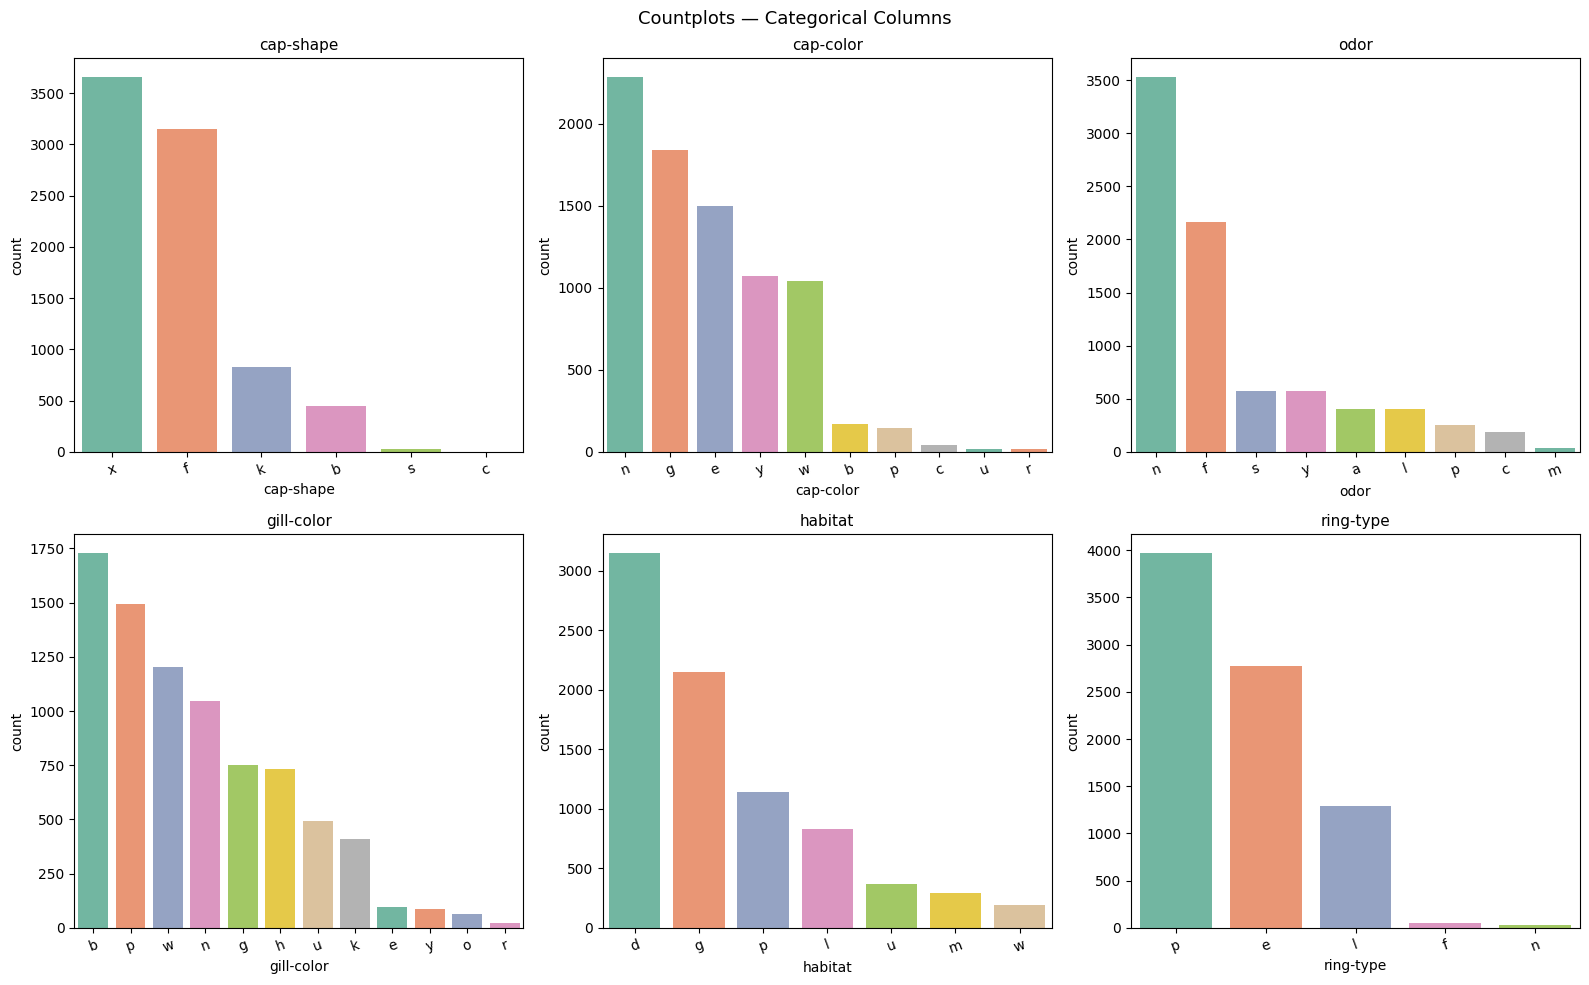

In [ ]:
cat_plot = ['cap-shape', 'cap-color', 'odor', 'gill-color', 'habitat', 'ring-type']
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
for ax, col in zip(axes.flatten(), cat_plot):
    sns.countplot(data=df, x=col, ax=ax, palette='Set2',
                  order=df[col].value_counts().index)
    ax.set_title(col, fontsize=11)
    ax.tick_params(axis='x', rotation=20)
plt.suptitle('Countplots — Categorical Columns', fontsize=13)
plt.tight_layout()
plt.show()

In [ ]:
df['class'].value_counts().to_frame('count')

,count
class,
e,4208
p,3916


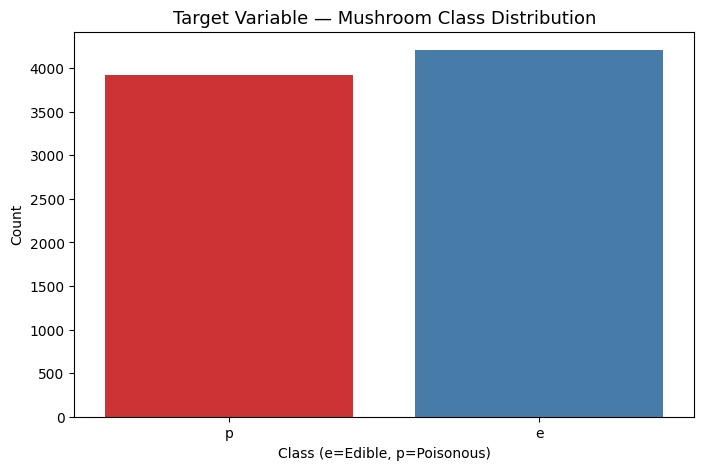

In [ ]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='class', palette='Set1')
plt.title('Target Variable — Mushroom Class Distribution', fontsize=13)
plt.xlabel('Class (e=Edible, p=Poisonous)')
plt.ylabel('Count')
plt.show()

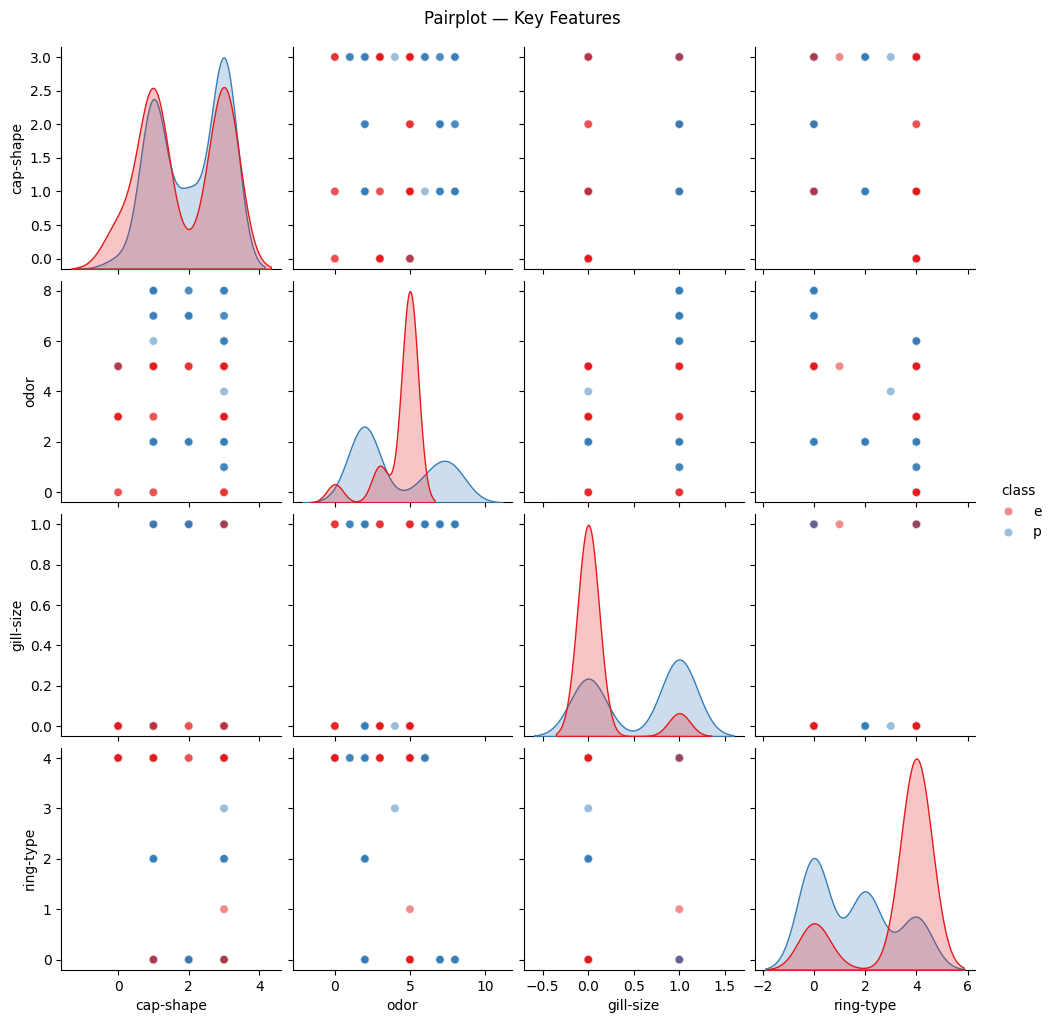

In [ ]:
samp     = df.sample(min(200, len(df)), random_state=42)
samp_num = samp.apply(le_temp.fit_transform)
samp_num['class'] = samp['class'].values
sns.pairplot(samp_num[['cap-shape','odor','gill-size','ring-type','class']],
             hue='class', palette='Set1', plot_kws={'alpha': 0.5})
plt.suptitle('Pairplot — Key Features', y=1.02, fontsize=12)
plt.show()

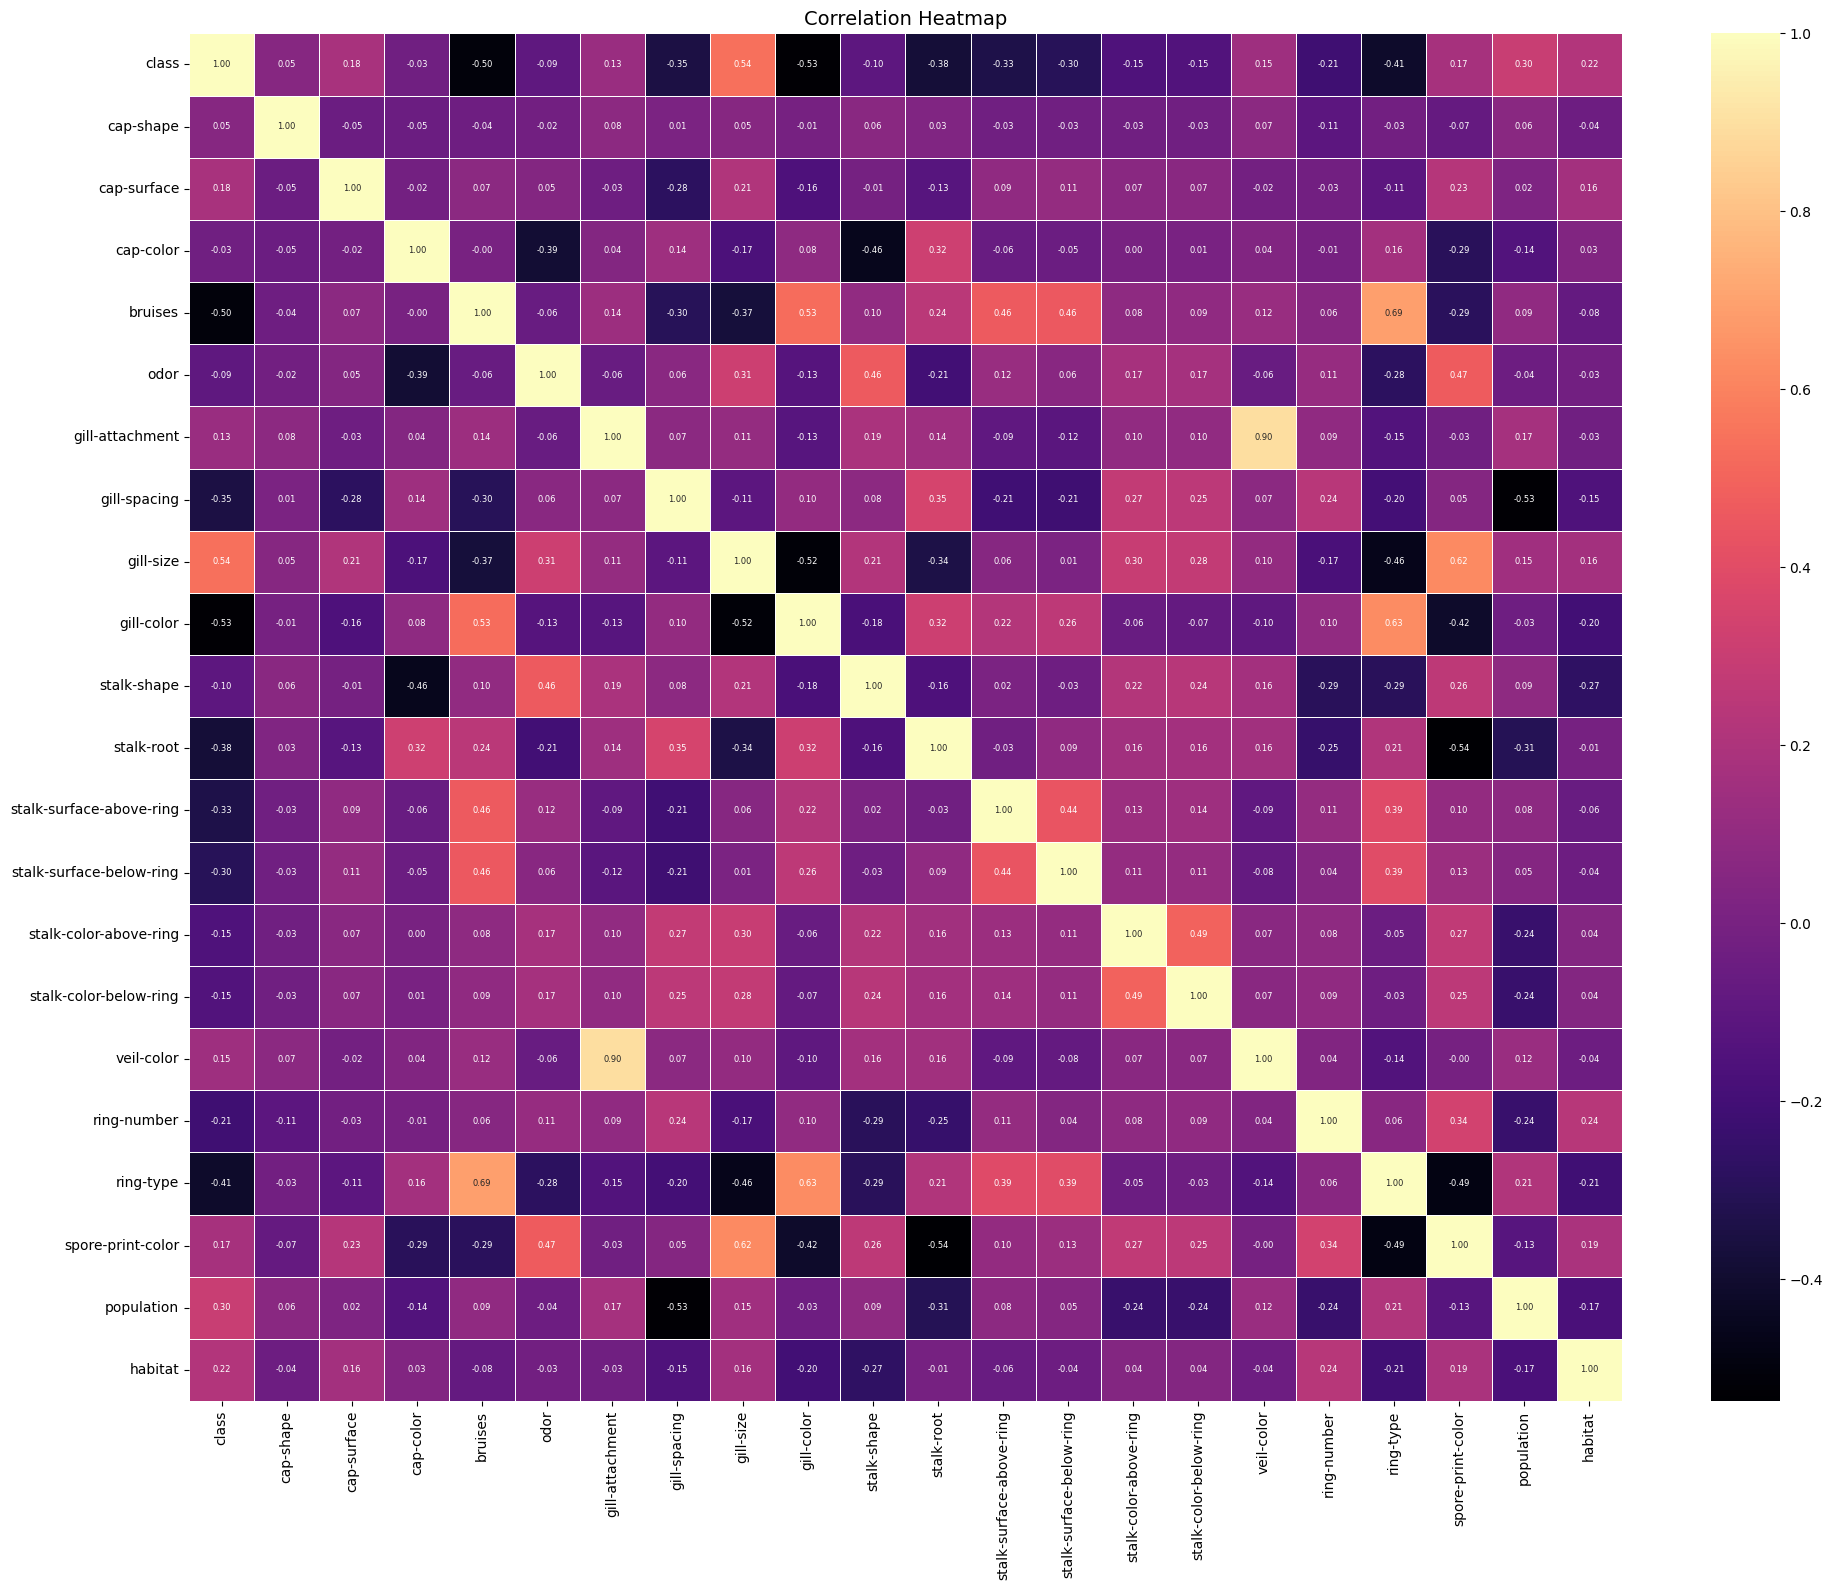

In [ ]:
df_num_no_veil = df_num.drop(columns=['veil-type'], errors='ignore')
corr_matrix = df_num_no_veil.corr()
plt.figure(figsize=(20, 16))
sns.heatmap(corr_matrix, annot=True, fmt='.2f',
            cmap='magma', linewidths=0.5, linecolor='white', annot_kws={'size': 6})
plt.title('Correlation Heatmap', fontsize=14)
plt.tight_layout()
plt.show()

### **Feature Engineering:**

In [ ]:
df_enc = df.copy()
le2 = LabelEncoder()
for col in df_enc.columns:
    df_enc[col] = le2.fit_transform(df_enc[col])
df_enc.head()

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,1,5,2,4,1,6,1,0,1,4,...,2,7,7,0,2,1,4,2,3,5
1,0,5,2,9,1,0,1,0,0,4,...,2,7,7,0,2,1,4,3,2,1
2,0,0,2,8,1,3,1,0,0,5,...,2,7,7,0,2,1,4,3,2,3
3,1,5,3,8,1,6,1,0,1,5,...,2,7,7,0,2,1,4,2,3,5
4,0,5,2,3,0,5,1,1,0,4,...,2,7,7,0,2,1,0,3,0,1


### **Data Preprocessing:**

In [ ]:
X = df_enc.drop('class', axis=1)
y = df_enc['class'].astype(int)
y.value_counts().to_frame('count')

,count
class,
0,4208
1,3916


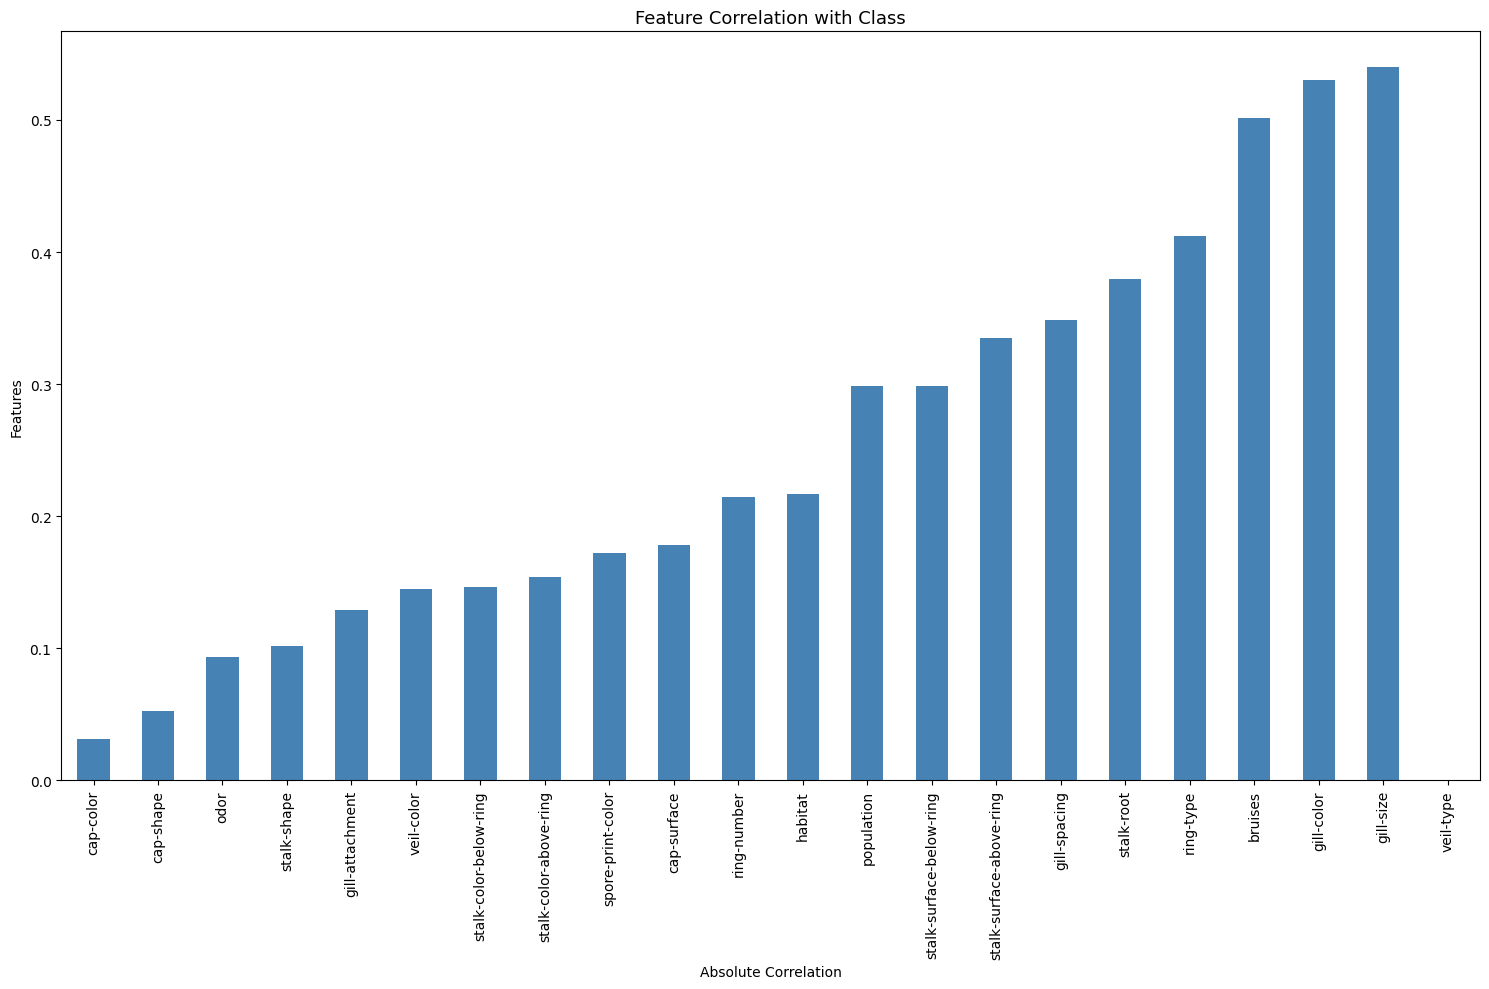

In [ ]:
corr_vals = df_enc.corr(numeric_only=True)['class'].drop('class').abs().sort_values()
plt.figure(figsize=(15, 10))
corr_vals.plot(kind='bar', color='steelblue')
plt.title('Feature Correlation with Class', fontsize=13)
plt.xlabel('Absolute Correlation')
plt.ylabel('Features')
plt.tight_layout()
plt.show()

### **Train test split:**

In [ ]:
X_np = X.to_numpy()
y_np = y.to_numpy()
X_train, X_test, y_train, y_test = train_test_split(
    X_np, y_np, test_size=0.2, random_state=42, stratify=y_np)
pd.Series(y_train).value_counts().to_frame('train_class_count')

,train_class_count
0,3366
1,3133


### **Feature Scaling:**

In [ ]:
scaler  = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

### **Model Training:**

In [ ]:
model = XGBClassifier(n_estimators=50, max_depth=2, learning_rate=0.1,
                      subsample=0.8, colsample_bytree=0.8,
                      eval_metric='logloss', random_state=42)
model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=2, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=50, n_jobs=None,
              num_parallel_tree=None, ...)

In [ ]:
y_proba = model.predict_proba(X_test)[:, 1]
y_pred  = model.predict(X_test)

### **Model Evaluation:**

In [ ]:
pd.DataFrame({
    'Metric': ['Accuracy','Precision','Recall','F1 Score','AUC Score'],
    'Score':  [round(accuracy_score(y_test,  y_pred),                   4),
               round(precision_score(y_test, y_pred, zero_division=0),  4),
               round(recall_score(y_test,    y_pred, zero_division=0),  4),
               round(f1_score(y_test,        y_pred, zero_division=0),  4),
               round(roc_auc_score(y_test,   y_proba),                  4)]
})

,Metric,Score
0,Accuracy,0.9932
1,Precision,1.0000
2,Recall,0.9860
3,F1 Score,0.9929
4,AUC Score,1.0000


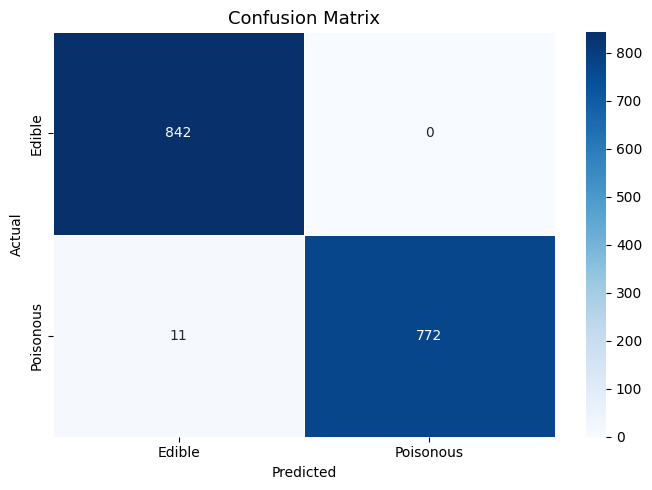

In [ ]:
plt.figure(figsize=(7, 5))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d',
            cmap='Blues', linewidths=0.5,
            xticklabels=['Edible','Poisonous'],
            yticklabels=['Edible','Poisonous'])
plt.title('Confusion Matrix', fontsize=13)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

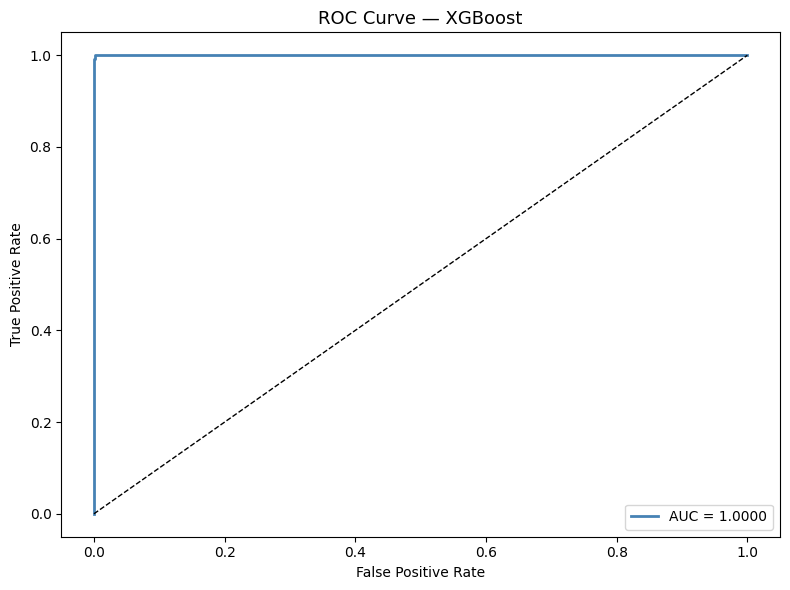

In [ ]:
fpr, tpr, _ = roc_curve(y_test, y_proba)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='steelblue', lw=2,
         label=f'AUC = {roc_auc_score(y_test, y_proba):.4f}')
plt.plot([0,1],[0,1],'k--', lw=1)
plt.title('ROC Curve — XGBoost', fontsize=13)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.tight_layout()
plt.show()

### **Train vs test score check:**

In [ ]:
pd.DataFrame({
    'Set':      ['Train', 'Test'],
    'Accuracy': [round(accuracy_score(y_train, model.predict(X_train)), 4),
                 round(accuracy_score(y_test,  y_pred), 4)]
})

,Set,Accuracy
0,Train,0.9918
1,Test,0.9932


### **Hyperparameter Tuning (GridSearchCV):**

In [ ]:
param_grid = {'n_estimators': [100, 200], 'max_depth': [3, 4],
              'learning_rate': [0.05, 0.1], 'subsample': [0.8, 1.0]}
grid = GridSearchCV(
    XGBClassifier(eval_metric='logloss', random_state=42),
    param_grid, cv=3, scoring='accuracy', n_jobs=-1)
grid.fit(X_train, y_train)
pd.DataFrame({'Best Params': [str(grid.best_params_)],
              'Best Score':  [round(grid.best_score_, 4)]})

,Best Params,Best Score
0,"{'learning_rate': 0.05, 'max_depth': 3, 'n_est...",0.9992


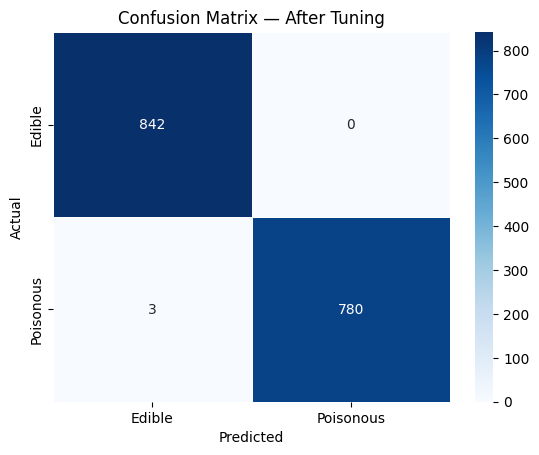

In [ ]:
y_pred_tuned = (grid.best_estimator_.predict_proba(X_test)[:, 1] >= 0.8).astype(int)
sns.heatmap(confusion_matrix(y_test, y_pred_tuned), annot=True, fmt='d',
            cmap='Blues', linewidths=0.5,
            xticklabels=['Edible','Poisonous'],
            yticklabels=['Edible','Poisonous'])
plt.title('Confusion Matrix — After Tuning')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

### **Cross validation:**

In [ ]:
best  = grid.best_params_
cv_sc = cross_val_score(
    XGBClassifier(**best, eval_metric='logloss', random_state=42),
    X_train, y_train, cv=5, scoring='accuracy')
pd.DataFrame({'CV Mean': [round(cv_sc.mean(), 4)],
              'CV Std':  [round(cv_sc.std(),  4)]})

,CV Mean,CV Std
0,0.9994,0.0012


### **Pipeline (final packaging):**

In [ ]:
final_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model',  XGBClassifier(n_estimators=50, max_depth=2, learning_rate=0.1,
                              subsample=0.8, colsample_bytree=0.8,
                              eval_metric='logloss', random_state=42))
])
final_pipe.fit(X_train, y_train)
pd.DataFrame({'Pipeline Score': [round(final_pipe.score(X_test, y_test), 4)]})

,Pipeline Score
0,0.9932


### **Final Output:**

In [ ]:
final_accuracy = final_pipe.score(X_test, y_test)
final_metrics_df = pd.DataFrame({
    'Metric': ['Pipeline Score'],
    'Value': [round(final_accuracy, 4)]
})
display(final_metrics_df)

,Metric,Value
0,Pipeline Score,0.9932


## **Conclusion:**
*   The dataset, comprising various mushroom characteristics, was successfully loaded and explored, revealing no missing values or duplicates.
*   Through data preprocessing, including label encoding and feature scaling, the data was prepared for machine learning.
*   An XGBoost classifier was trained, achieving high accuracy and robust performance, indicating its effectiveness in classifying mushrooms as edible or poisonous.